# Code to make heatmaps using latent representations of data in LLMs!

In [1]:
## == CUSTOM HELPER FUNCTIONS == ##
import torch
import gc
import analysis_functions as topo
import heatmap_functions as ling

/home/kim/TDA_RI/TDA_reason-interpret/venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [2]:
## == DATASETS == ##
# [0]: hellaswag, [1]-[5]: mmlu, [6]: mcqa
datasets = [["hellaswag", "~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv"],
            ["mmlu_law", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv"],
            ["mmlu_math", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv"],
            ["mmlu_misc", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv"],
            ["mmlu_moral", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv"],
            ["mmlu_psych", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv"],
            ["mcqa", "~/TDA_RI/TDA_reason-interpret/datasets/mcqa.csv"]]

## == MODELS == ##
# [0]: Llama, [1]: Qwen, [2]: Mistral
models = [["Llama 3.1 8B", "meta-llama/Llama-3.1-8B", "llama"],
          ["Qwen 3 8B", "Qwen/Qwen3-8B", "qwen"],
          ["Mistral 7B v0.3", "mistralai/Mistral-7B-v0.3", "mistral"]]

In [3]:
# import pandas as pd
# import torch
# import gc
# import os

# # ---------------------------------------------------------
# # TEST: process_texts() on 5 HellaSwag prompts
# # ---------------------------------------------------------

# DATASET_PATH = "~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv"
# MODEL_ID = "meta-llama/Llama-3.1-8B"

# # ---------------------------------------------------------
# # 1. Load dataset
# # ---------------------------------------------------------

# dataset_path = os.path.expanduser(DATASET_PATH)

# questions = pd.read_csv(dataset_path)

# print("Dataset shape:", questions.shape)
# print("Dataset columns:", questions.columns.tolist())

# # Take only first 5 prompts
# test_prompts = questions["prompt"].iloc[:5].tolist()

# print("\nNumber of test prompts:", len(test_prompts))

# for i, prompt in enumerate(test_prompts):
#     print(f"\n--- Prompt {i} ---")
#     print(prompt[:500])


# # ---------------------------------------------------------
# # 2. Run process_texts()
# # ---------------------------------------------------------

# print("\n" + "=" * 70)
# print("RUNNING process_texts()")
# print("=" * 70)

# test_results = topo.process_texts(
#     texts=test_prompts,
#     text_cat="hellaswag",
#     model_id=MODEL_ID
# )


# # ---------------------------------------------------------
# # 3. Inspect results
# # ---------------------------------------------------------

# print("\n" + "=" * 70)
# print("RESULTS")
# print("=" * 70)

# print("Result shape:", test_results.shape)

# print("\nColumns:")
# print(test_results.columns.tolist())

# print("\nDataFrame:")
# print(test_results)

# print("\nNaN counts:")
# print(test_results.isna().sum())

# print("\nCorrectness counts:")
# print(test_results["correctness"].value_counts(dropna=False))

In [4]:
# ## RUN IF TDA INFO FROM DATASET NOT STORED FOR MODEL!
# for dataset in datasets:
#     ling_feat = ling.get_ling_feat(dataset, create = True)
#     # for model in models:
#     #     gc.collect()
#     #     torch.cuda.empty_cache()
#     #     torch.cuda.ipc_collect()
#     #     topo_feat = topo.get_top_feat(model, dataset, create = True)

+--------------------+---------------------+------------------------+------------------------+------------------------+--------------------+-----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second  |       mean_feat        |    betti_curve     |  persistence_entropy  |
+--------------------+---------------------+------------------------+------------------------+------------------------+--------------------+-----------------------+
|    correct_0dim    |        91.23        |   0.770020751953125    |   0.008648681640625    |   0.6828568411290499   | 80.22120000000001  |   4.478512725791018   |
| correct_0dim_stdv  |  2.4040309162871942 | 0.0013049198754257628  | 0.0007713429046065347  | 0.0009078468055536556  | 2.132963051577298  |  0.025963382849107947 |
|    correct_1dim    |         0.0         |          0.0           |          0.0           |          0.0           |        0.0         |          0.0          |
|  correct

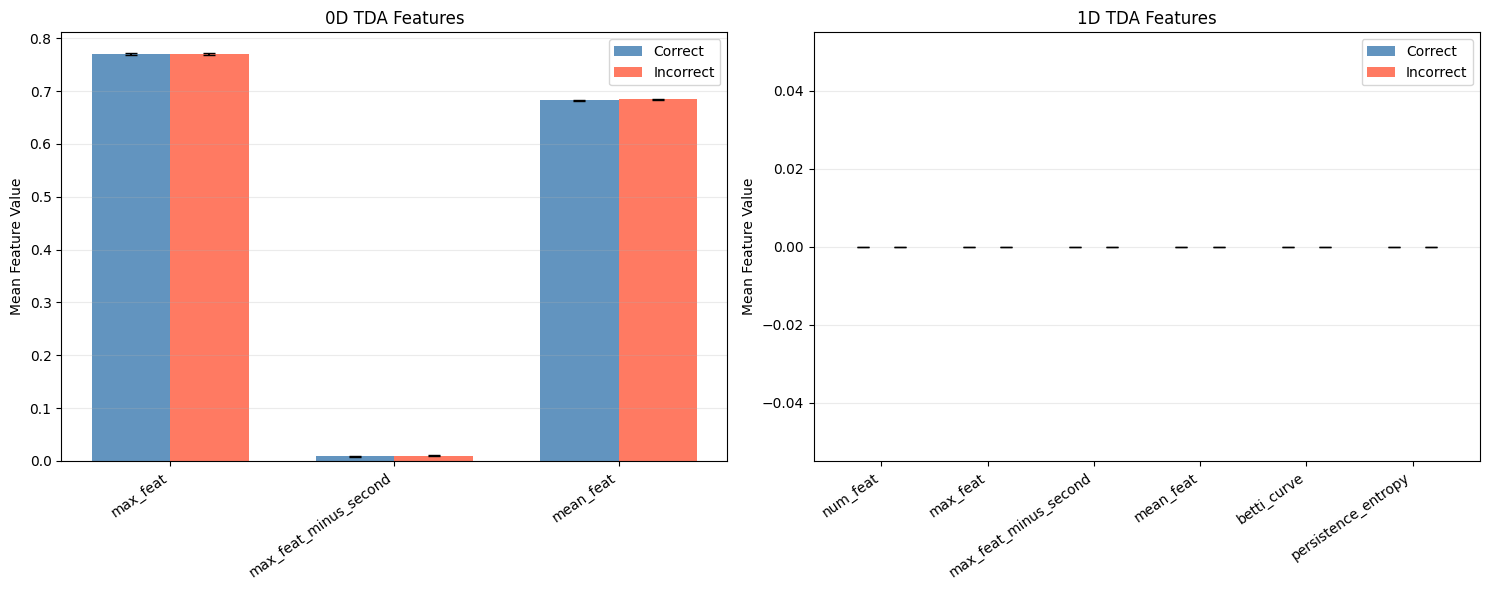

0

In [5]:
# prelim analysis
topo.analyze_feats(models[0], datasets[0])

In [6]:
# from lm_eval.tasks import TaskManager
# import re

# # Insert your refactored evaluate_model code here or import it
# # from analysis_functions import evaluate_model

# def test_evaluate_model():
#     print("--- Starting evaluate_model Unit Tests ---\n")
    
#     # 1. Test Task Setup (MMLU sample test)
#     try:
#         task_name = "mmlu_abstract_algebra"
#         print(f"Testing task: {task_name}...")
        
#         # Test valid prediction matching correct answer
#         result_correct = topo.evaluate_model(task_name, q_index=0, llm_answer="Answer: A")
#         print(f"  [PASS] Single document run returned: {result_correct}")
        
#         # Test alternative format (numeric string)
#         result_num = topo.evaluate_model(task_name, q_index=0, llm_answer="0")
#         print(f"  [PASS] Numeric answer format handled successfully.")
        
#     except Exception as e:
#         print(f"  [FAIL] Error during task execution: {e}")

#     # 2. Test Bounds Protection
#     print("\nTesting out-of-bounds index handling...")
#     try:
#         # Request an index that is guaranteed to be out of bounds
#         topo.evaluate_model("mmlu_abstract_algebra", q_index=999999, llm_answer="Answer: A")
#         print("  [FAIL] Expected IndexError was not raised.")
#     except IndexError as e:
#         print(f"  [PASS] Out-of-bounds correctly caught: {e}")
#         print(f"  [FAIL] Unexpected exception type raised: {type(e).__name__}: {e}")

#     # 3. Test Invalid LLM Output Parsing
#     print("\nTesting malformed LLM outputs...")
#     try:
#         res = topo.evaluate_model("mmlu_abstract_algebra", q_index=0, llm_answer="I don't know the answer.")
#         print(f"  [PASS] Unparseable answer handled gracefully (returned {res}).")
#     except Exception as e:
#         print(f"  [FAIL] Unparseable answer raised an exception: {e}")

#     print("\n--- All Tests Completed ---")

# if __name__ == "__main__":
#     test_evaluate_model()

In [7]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[1], datasets[0], create = True)

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  0%|                                       | 1/1000 [00:10<2:59:52, 10.80s/it]

Raw prompt attention shape: torch.Size([1, 32, 71, 71])
Final prompt attention shape: (71, 71)
answer:  2


  0%|                                       | 2/1000 [00:21<2:54:42, 10.50s/it]

...

100%|████████████████████████████████████▉| 999/1000 [2:52:42<00:10, 10.40s/it]

Raw prompt attention shape: torch.Size([1, 32, 240, 240])
Final prompt attention shape: (240, 240)
answer:  1


100%|████████████████████████████████████| 1000/1000 [2:52:52<00:00, 10.37s/it]

Raw prompt attention shape: torch.Size([1, 32, 196, 196])
Final prompt attention shape: (196, 196)
answer:  2


Added questions from hellaswag for qwen!


In [8]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[2], datasets[0], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                       | 1/1000 [00:09<2:35:49,  9.36s/it]

Raw prompt attention shape: torch.Size([1, 32, 79, 79])
Final prompt attention shape: (79, 79)
answer:  2


  0%|                                       | 2/1000 [00:18<2:35:35,  9.35s/it]

Raw prompt attention shape: torch.Size([1, 32, 71, 71])
Final prompt attention shape: (71, 71)
answer:  2


...

100%|████████████████████████████████████▉| 999/1000 [2:24:24<00:08,  8.98s/it]

Raw prompt attention shape: torch.Size([1, 32, 258, 258])
Final prompt attention shape: (258, 258)
answer:  1


100%|████████████████████████████████████| 1000/1000 [2:24:25<00:00,  8.67s/it]

Raw prompt attention shape: torch.Size([1, 32, 224, 224])
Final prompt attention shape: (224, 224)
answer:  2


Added questions from hellaswag for mistral!


In [9]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[0], datasets[1], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                         | 2/1000 [00:00<05:43,  2.90it/s]

Raw prompt attention shape: torch.Size([1, 32, 512, 512])
Final prompt attention shape: (512, 512)
answer:  0
Raw prompt attention shape: torch.Size([1, 32, 273, 273])
Final prompt attention shape: (273, 273)
answer:  1


  0%|▏                                        | 4/1000 [00:01<03:37,  4.58it/s]

Raw prompt attention shape: torch.Size([1, 32, 398, 398])
Final prompt attention shape: (398, 398)
answer:  0
Raw prompt attention shape: torch.Size([1, 32, 253, 253])
Final prompt attention shape: (253, 253)
answer:  1


...

100%|██████████████████████████████████████▉| 998/1000 [04:13<00:02,  1.19s/it]

Raw prompt attention shape: torch.Size([1, 32, 392, 392])
Final prompt attention shape: (392, 392)
answer:  2
Raw prompt attention shape: torch.Size([1, 32, 303, 303])
Final prompt attention shape: (303, 303)
answer:  1


100%|██████████████████████████████████████| 1000/1000 [04:13<00:00,  3.95it/s]

Raw prompt attention shape: torch.Size([1, 32, 377, 377])
Final prompt attention shape: (377, 377)
answer:  3
Raw prompt attention shape: torch.Size([1, 32, 230, 230])
Final prompt attention shape: (230, 230)
answer:  2


Added questions from mmlu_law for llama!


In [10]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[1], datasets[1], create = True)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  0%|                                       | 1/1000 [00:10<2:56:25, 10.60s/it]

Raw prompt attention shape: torch.Size([1, 32, 512, 512])
Final prompt attention shape: (512, 512)
answer:  0


  0%|                                       | 2/1000 [00:21<2:54:39, 10.50s/it]

Raw prompt attention shape: torch.Size([1, 32, 272, 272])
Final prompt attention shape: (272, 272)
answer:  1


...

100%|████████████████████████████████████▉| 999/1000 [2:52:52<00:10, 10.48s/it]

Raw prompt attention shape: torch.Size([1, 32, 390, 390])
Final prompt attention shape: (390, 390)
answer:  3


100%|████████████████████████████████████| 1000/1000 [2:53:02<00:00, 10.38s/it]

Raw prompt attention shape: torch.Size([1, 32, 248, 248])
Final prompt attention shape: (248, 248)
answer:  2


Added questions from mmlu_law for qwen!


In [11]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[2], datasets[1], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                       | 1/1000 [00:04<1:22:24,  4.95s/it]

Raw prompt attention shape: torch.Size([1, 32, 512, 512])
Final prompt attention shape: (512, 512)
answer:  0


  0%|                                       | 2/1000 [00:14<2:06:50,  7.63s/it]

Raw prompt attention shape: torch.Size([1, 32, 303, 303])
Final prompt attention shape: (303, 303)
answer:  1


...

100%|████████████████████████████████████▉| 999/1000 [2:05:23<00:08,  8.29s/it]

Raw prompt attention shape: torch.Size([1, 32, 418, 418])
Final prompt attention shape: (418, 418)
answer:  3


100%|████████████████████████████████████| 1000/1000 [2:05:28<00:00,  7.53s/it]

Raw prompt attention shape: torch.Size([1, 32, 263, 263])
Final prompt attention shape: (263, 263)
answer:  2


Added questions from mmlu_law for mistral!


In [12]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[0], datasets[2], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  1%|▏                                         | 2/378 [00:01<04:58,  1.26it/s]

Raw prompt attention shape: torch.Size([1, 32, 45, 45])
Final prompt attention shape: (45, 45)
answer:  2
Raw prompt attention shape: torch.Size([1, 32, 59, 59])
Final prompt attention shape: (59, 59)
answer:  2


  1%|▍                                         | 4/378 [00:02<02:04,  3.02it/s]

Raw prompt attention shape: torch.Size([1, 32, 41, 41])
Final prompt attention shape: (41, 41)
answer:  3
Raw prompt attention shape: torch.Size([1, 32, 59, 59])
Final prompt attention shape: (59, 59)
answer:  1


...

 99%|███████████████████████████████████████▊| 376/378 [06:06<00:00,  2.79it/s]

Raw prompt attention shape: torch.Size([1, 32, 50, 50])
Final prompt attention shape: (50, 50)
answer:  0
Raw prompt attention shape: torch.Size([1, 32, 79, 79])
Final prompt attention shape: (79, 79)
answer:  3


100%|████████████████████████████████████████| 378/378 [06:07<00:00,  1.03it/s]

Raw prompt attention shape: torch.Size([1, 32, 58, 58])
Final prompt attention shape: (58, 58)
answer:  2
Raw prompt attention shape: torch.Size([1, 32, 79, 79])
Final prompt attention shape: (79, 79)
answer:  1


Added questions from mmlu_math for llama!


In [13]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[1], datasets[2], create = True)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  0%|                                        | 1/378 [00:10<1:04:27, 10.26s/it]

Raw prompt attention shape: torch.Size([1, 32, 47, 47])
Final prompt attention shape: (47, 47)
answer:  2


  1%|▏                                       | 2/378 [00:20<1:04:18, 10.26s/it]

Raw prompt attention shape: torch.Size([1, 32, 59, 59])
Final prompt attention shape: (59, 59)
answer:  2


...

Raw prompt attention shape: torch.Size([1, 32, 98, 98])
Final prompt attention shape: (98, 98)
answer:  3


100%|█████████████████████████████████████▉| 377/378 [1:04:21<00:10, 10.27s/it]

Raw prompt attention shape: torch.Size([1, 32, 69, 69])
Final prompt attention shape: (69, 69)
answer:  2


100%|██████████████████████████████████████| 378/378 [1:04:32<00:00, 10.24s/it]

Raw prompt attention shape: torch.Size([1, 32, 84, 84])
Final prompt attention shape: (84, 84)
answer:  1
Added questions from mmlu_math for qwen!


In [14]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[2], datasets[2], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                          | 1/378 [00:01<09:58,  1.59s/it]

Raw prompt attention shape: torch.Size([1, 32, 50, 50])
Final prompt attention shape: (50, 50)
answer:  2


  1%|▏                                         | 2/378 [00:05<18:20,  2.93s/it]

Raw prompt attention shape: torch.Size([1, 32, 64, 64])
Final prompt attention shape: (64, 64)
answer:  2


...

Raw prompt attention shape: torch.Size([1, 32, 101, 101])
Final prompt attention shape: (101, 101)
answer:  3


100%|███████████████████████████████████████▉| 377/378 [45:11<00:08,  8.87s/it]

Raw prompt attention shape: torch.Size([1, 32, 72, 72])
Final prompt attention shape: (72, 72)
answer:  2


100%|████████████████████████████████████████| 378/378 [45:16<00:00,  7.19s/it]

Raw prompt attention shape: torch.Size([1, 32, 91, 91])
Final prompt attention shape: (91, 91)
answer:  1
Added questions from mmlu_math for mistral!


In [15]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[0], datasets[3], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                          | 2/783 [00:00<01:24,  9.20it/s]

Raw prompt attention shape: torch.Size([1, 32, 51, 51])
Final prompt attention shape: (51, 51)
answer:  2
Raw prompt attention shape: torch.Size([1, 32, 75, 75])
Final prompt attention shape: (75, 75)
answer:  1


  1%|▏                                         | 4/783 [00:00<01:22,  9.42it/s]

Raw prompt attention shape: torch.Size([1, 32, 39, 39])
Final prompt attention shape: (39, 39)
answer:  3
Raw prompt attention shape: torch.Size([1, 32, 38, 38])
Final prompt attention shape: (38, 38)
answer:  2


...

100%|███████████████████████████████████████▉| 781/783 [25:33<00:09,  4.80s/it]

Raw prompt attention shape: torch.Size([1, 32, 33, 33])
Final prompt attention shape: (33, 33)
answer:  3


100%|████████████████████████████████████████| 783/783 [25:33<00:00,  1.96s/it]

Raw prompt attention shape: torch.Size([1, 32, 29, 29])
Final prompt attention shape: (29, 29)
answer:  0
Raw prompt attention shape: torch.Size([1, 32, 101, 101])
Final prompt attention shape: (101, 101)
answer:  3


Added questions from mmlu_misc for llama!


In [16]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[1], datasets[3], create = True)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  0%|                                        | 1/783 [00:10<2:13:41, 10.26s/it]

Raw prompt attention shape: torch.Size([1, 32, 50, 50])
Final prompt attention shape: (50, 50)
answer:  2


  0%|                                        | 2/783 [00:20<2:13:38, 10.27s/it]

Raw prompt attention shape: torch.Size([1, 32, 74, 74])
Final prompt attention shape: (74, 74)
answer:  1


...

Raw prompt attention shape: torch.Size([1, 32, 32, 32])
Final prompt attention shape: (32, 32)
answer:  3


100%|█████████████████████████████████████▉| 782/783 [2:12:11<00:10, 10.25s/it]

Raw prompt attention shape: torch.Size([1, 32, 28, 28])
Final prompt attention shape: (28, 28)
answer:  0


100%|██████████████████████████████████████| 783/783 [2:12:22<00:00, 10.14s/it]

Raw prompt attention shape: torch.Size([1, 32, 100, 100])
Final prompt attention shape: (100, 100)
answer:  3
Added questions from mmlu_misc for qwen!


In [17]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[2], datasets[3], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                        | 1/783 [00:09<2:01:38,  9.33s/it]

Raw prompt attention shape: torch.Size([1, 32, 57, 57])
Final prompt attention shape: (57, 57)
answer:  2


  0%|                                        | 2/783 [00:15<1:33:56,  7.22s/it]

Raw prompt attention shape: torch.Size([1, 32, 84, 84])
Final prompt attention shape: (84, 84)
answer:  1


...

100%|█████████████████████████████████████▉| 782/783 [1:58:53<00:08,  9.00s/it]

Raw prompt attention shape: torch.Size([1, 32, 33, 33])
Final prompt attention shape: (33, 33)
answer:  0


100%|██████████████████████████████████████| 783/783 [1:59:02<00:00,  9.12s/it]

Raw prompt attention shape: torch.Size([1, 32, 111, 111])
Final prompt attention shape: (111, 111)
answer:  3


Added questions from mmlu_misc for mistral!


In [18]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[0], datasets[4], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                        | 1/895 [00:09<2:27:14,  9.88s/it]

Raw prompt attention shape: torch.Size([1, 32, 104, 104])
Final prompt attention shape: (104, 104)
answer:  3


  0%|▏                                       | 3/895 [00:16<1:02:26,  4.20s/it]

Raw prompt attention shape: torch.Size([1, 32, 97, 97])
Final prompt attention shape: (97, 97)
answer:  0
Raw prompt attention shape: torch.Size([1, 32, 103, 103])
Final prompt attention shape: (103, 103)
answer:  3


...

100%|█████████████████████████████████████▉| 894/895 [1:31:07<00:06,  6.29s/it]

Raw prompt attention shape: torch.Size([1, 32, 98, 98])
Final prompt attention shape: (98, 98)
answer:  0


100%|██████████████████████████████████████| 895/895 [1:31:17<00:00,  6.12s/it]

Raw prompt attention shape: torch.Size([1, 32, 113, 113])
Final prompt attention shape: (113, 113)
answer:  1


Added questions from mmlu_moral for llama!


In [19]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[1], datasets[4], create = True)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  0%|                                        | 1/895 [00:10<2:33:33, 10.31s/it]

Raw prompt attention shape: torch.Size([1, 32, 105, 105])
Final prompt attention shape: (105, 105)
answer:  3


  0%|                                        | 2/895 [00:20<2:33:14, 10.30s/it]

Raw prompt attention shape: torch.Size([1, 32, 98, 98])
Final prompt attention shape: (98, 98)
answer:  0


...

100%|█████████████████████████████████████▉| 894/895 [2:32:56<00:10, 10.22s/it]

Raw prompt attention shape: torch.Size([1, 32, 99, 99])
Final prompt attention shape: (99, 99)
answer:  0


100%|██████████████████████████████████████| 895/895 [2:33:06<00:00, 10.26s/it]

Raw prompt attention shape: torch.Size([1, 32, 114, 114])
Final prompt attention shape: (114, 114)
answer:  1


Added questions from mmlu_moral for qwen!


In [20]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[2], datasets[4], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                        | 1/895 [00:09<2:19:52,  9.39s/it]

Raw prompt attention shape: torch.Size([1, 32, 118, 118])
Final prompt attention shape: (118, 118)
answer:  3


  0%|                                        | 2/895 [00:18<2:19:39,  9.38s/it]

Raw prompt attention shape: torch.Size([1, 32, 110, 110])
Final prompt attention shape: (110, 110)
answer:  0


...

100%|█████████████████████████████████████▉| 894/895 [2:19:38<00:09,  9.40s/it]

Raw prompt attention shape: torch.Size([1, 32, 112, 112])
Final prompt attention shape: (112, 112)
answer:  0


100%|██████████████████████████████████████| 895/895 [2:19:47<00:00,  9.37s/it]

Raw prompt attention shape: torch.Size([1, 32, 129, 129])
Final prompt attention shape: (129, 129)
answer:  1


Added questions from mmlu_moral for mistral!


In [21]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[0], datasets[5], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|▏                                         | 2/612 [00:00<01:08,  8.89it/s]

Raw prompt attention shape: torch.Size([1, 32, 84, 84])
Final prompt attention shape: (84, 84)
answer:  3
Raw prompt attention shape: torch.Size([1, 32, 41, 41])
Final prompt attention shape: (41, 41)
answer:  2


  1%|▎                                         | 4/612 [00:00<01:10,  8.60it/s]

Raw prompt attention shape: torch.Size([1, 32, 114, 114])
Final prompt attention shape: (114, 114)
answer:  1
Raw prompt attention shape: torch.Size([1, 32, 51, 51])
Final prompt attention shape: (51, 51)
answer:  1


...

Raw prompt attention shape: torch.Size([1, 32, 49, 49])
Final prompt attention shape: (49, 49)
answer:  2
Raw prompt attention shape: torch.Size([1, 32, 63, 63])
Final prompt attention shape: (63, 63)
answer:  3


100%|███████████████████████████████████████▉| 611/612 [01:08<00:00,  9.27it/s]

Raw prompt attention shape: torch.Size([1, 32, 87, 87])
Final prompt attention shape: (87, 87)
answer:  2
Raw prompt attention shape: torch.Size([1, 32, 92, 92])
Final prompt attention shape: (92, 92)
answer:  0


100%|████████████████████████████████████████| 612/612 [01:08<00:00,  8.94it/s]


Raw prompt attention shape: torch.Size([1, 32, 43, 43])
Final prompt attention shape: (43, 43)
answer:  1
Added questions from mmlu_psych for llama!


In [22]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[1], datasets[5], create = True)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  0%|                                        | 1/612 [00:10<1:44:57, 10.31s/it]

Raw prompt attention shape: torch.Size([1, 32, 83, 83])
Final prompt attention shape: (83, 83)
answer:  3


  0%|▏                                       | 2/612 [00:20<1:44:34, 10.29s/it]

Raw prompt attention shape: torch.Size([1, 32, 40, 40])
Final prompt attention shape: (40, 40)
answer:  2


...

100%|█████████████████████████████████████▉| 611/612 [1:44:23<00:10, 10.26s/it]

Raw prompt attention shape: torch.Size([1, 32, 91, 91])
Final prompt attention shape: (91, 91)
answer:  0


100%|██████████████████████████████████████| 612/612 [1:44:33<00:00, 10.25s/it]

Raw prompt attention shape: torch.Size([1, 32, 42, 42])
Final prompt attention shape: (42, 42)
answer:  1


Added questions from mmlu_psych for qwen!


In [23]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[2], datasets[5], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                        | 1/612 [00:09<1:35:26,  9.37s/it]

Raw prompt attention shape: torch.Size([1, 32, 95, 95])
Final prompt attention shape: (95, 95)
answer:  3


  0%|▏                                       | 2/612 [00:18<1:35:04,  9.35s/it]

Raw prompt attention shape: torch.Size([1, 32, 47, 47])
Final prompt attention shape: (47, 47)
answer:  2


...

100%|█████████████████████████████████████▉| 611/612 [1:30:35<00:09,  9.36s/it]

Raw prompt attention shape: torch.Size([1, 32, 109, 109])
Final prompt attention shape: (109, 109)
answer:  0


100%|██████████████████████████████████████| 612/612 [1:30:44<00:00,  8.90s/it]

Raw prompt attention shape: torch.Size([1, 32, 49, 49])
Final prompt attention shape: (49, 49)
answer:  1


Added questions from mmlu_psych for mistral!


In [27]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
topo_feat = topo.get_top_feat(models[0], datasets[0], create = True)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  0%|                                         | 2/1000 [00:00<01:54,  8.74it/s]

Raw prompt attention shape: torch.Size([1, 32, 72, 72])
Final prompt attention shape: (72, 72)
answer:  2
Raw prompt attention shape: torch.Size([1, 32, 64, 64])
Final prompt attention shape: (64, 64)
answer:  2


  0%|                                       | 3/1000 [00:10<1:19:33,  4.79s/it]

Raw prompt attention shape: torch.Size([1, 32, 231, 231])
Final prompt attention shape: (231, 231)
answer:  0


...

100%|████████████████████████████████████▉| 998/1000 [1:13:34<00:09,  4.74s/it]

Raw prompt attention shape: torch.Size([1, 32, 234, 234])
Final prompt attention shape: (234, 234)
answer:  2
Raw prompt attention shape: torch.Size([1, 32, 213, 213])
Final prompt attention shape: (213, 213)
answer:  3


100%|████████████████████████████████████| 1000/1000 [1:13:44<00:00,  4.42s/it]

Raw prompt attention shape: torch.Size([1, 32, 241, 241])
Final prompt attention shape: (241, 241)
answer:  1
Raw prompt attention shape: torch.Size([1, 32, 197, 197])
Final prompt attention shape: (197, 197)
answer:  2


Added questions from hellaswag for llama!


In [26]:
for dataset in datasets:
    ling_feat = ling.get_ling_feat(dataset, create = True)

Added ling features for questions from hellaswag!
Added ling features for questions from mmlu_law!
Added ling features for questions from mmlu_math!
Added ling features for questions from mmlu_misc!
Added ling features for questions from mmlu_moral!
Added ling features for questions from mmlu_psych!


In [24]:
# heatmap labels
linguistic_labels = [['Linguistic Features',["num_tokens", "num_types", "avg_word_length", "char_count",
                        "ttr", "cttr", "herdan_c", "simpson_div", "yules_k",
                        "num_content_words", "lexical_density",
                        "avg_polysemy", "num_long_words", "long_word_ratio", "hapax_legomena", "hapax_ratio",
                        "num_stopwords", "stopword_ratio",
                        "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio",
                        "entropy", "top_word_freq",
                        "unique_bigram_approx"]]
]

tda_labels = [["Topological Features", ['Num_0dim', 'Max_0dim', 'Max_0dim_Minus_Second', 'Mean_0dim', 'betti_curve_0', 'persistence_entropy_0', 'Num_1dim', 'Max_1dim', 'Max_1dim_Minus_Second', 'Mean_1dim', 'betti_curve_1', 'persistence_entropy_1']],
              ["h0 Features", ["Num_0dim", "Max_0dim", "Mean_0dim", "betti_curve_0", "persistence_entropy_0"]],
              ["h1 Features", ["Num_1dim", "Max_1dim", "Mean_1dim", "betti_curve_1", "persistence_entropy_1"]]
]

print("# features: ", len(linguistic_labels[0][1]))

# features:  25
